# 01. 데이터 분석

Dialogue Summarization 데이터셋(DialogSum-KO)의 기본 통계, 분포, 특성을 분석합니다.

**데이터 구성**
- `train.csv` : 12,457개 (fname, dialogue, summary, topic)
- `dev.csv`   : 499개
- `test.csv`  : 499개 (summary 없음)


## 0. 환경 설정

In [ ]:
import os, sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from collections import Counter

# 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False
try:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = 'NanumGothic'
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    pass

ROOT = Path('..') 
DATA_DIR = ROOT / 'data' / 'raw'

print('설정 완료')

설정 완료


## 1. 데이터 로드

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
dev   = pd.read_csv(DATA_DIR / 'dev.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'train : {len(train):,}개')
print(f'dev   : {len(dev):,}개')
print(f'test  : {len(test):,}개')

train.head(3)

train : 12,457개
dev   : 499개
test  : 499개


,fname,dialogue,summary,topic
0,train_0,"#Person1#: 안녕하세요, 스미스씨. 저는 호킨스 의사입니다. 오늘 왜 오셨나...","스미스씨가 건강검진을 받고 있고, 호킨스 의사는 매년 건강검진을 받는 것을 권장합니...",건강검진 받기
1,train_1,"#Person1#: 안녕하세요, 파커 부인, 어떻게 지내셨나요?\n#Person2#...",파커 부인이 리키를 데리고 백신 접종을 하러 갔다. 피터스 박사는 기록을 확인한 후...,백신
2,train_2,"#Person1#: 실례합니다, 열쇠 한 묶음 보셨나요?\n#Person2#: 어떤...","#Person1#은 열쇠 한 묶음을 찾고 있고, 그것을 찾기 위해 #Person2#...",열쇠 찾기


## 2. 기본 통계

In [3]:
# 결측값 확인
print('=== 결측값 ===')  
for name, df in [('train', train), ('dev', dev), ('test', test)]:
    print(f'{name}: {df.isnull().sum().to_dict()}')

# 중복 확인
print('\n=== 중복 행 ===')
for name, df in [('train', train), ('dev', dev)]:
    print(f'{name} dialogue 중복: {df["dialogue"].duplicated().sum()}')
    print(f'{name} summary  중복: {df["summary"].duplicated().sum()}')

=== 결측값 ===
train: {'fname': 0, 'dialogue': 0, 'summary': 0, 'topic': 0}
dev: {'fname': 0, 'dialogue': 0, 'summary': 0, 'topic': 0}
test: {'fname': 0, 'dialogue': 0}

=== 중복 행 ===
train dialogue 중복: 38
train summary  중복: 16
dev dialogue 중복: 0
dev summary  중복: 0


## 3. 텍스트 길이 분석

In [4]:
def add_length_cols(df):
    df = df.copy()
    df['dialogue_len']  = df['dialogue'].str.len()
    df['dialogue_words'] = df['dialogue'].str.split().str.len()
    df['dialogue_turns'] = df['dialogue'].str.count(r'#Person\d+#:')
    if 'summary' in df.columns:
        df['summary_len']   = df['summary'].str.len()
        df['summary_words'] = df['summary'].str.split().str.len()
        df['compression_ratio'] = (df['summary_len'] / df['dialogue_len']).round(3)
    return df

train = add_length_cols(train)
dev   = add_length_cols(dev)
test  = add_length_cols(test)

cols = ['dialogue_len', 'dialogue_words', 'dialogue_turns', 'summary_len', 'summary_words', 'compression_ratio']
train[cols].describe().round(2)

,dialogue_len,dialogue_words,dialogue_turns,summary_len,summary_words,compression_ratio
count,12457.00,12457.00,12457.00,12457.00,12457.00,12457.00
mean,438.77,90.66,9.49,87.40,16.92,0.21
std,220.13,48.95,4.15,37.64,7.85,0.07
min,99.00,20.00,2.00,19.00,4.00,0.05
25%,299.00,58.00,7.00,61.00,11.00,0.17
50%,396.00,80.00,9.00,80.00,16.00,0.20
75%,540.00,113.00,12.00,106.00,21.00,0.25
max,2546.00,606.00,61.00,478.00,99.00,0.86


/tmp/ipykernel_335388/2406788395.py:20: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2406788395.py:20: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2406788395.py:20: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2406788395.py:20: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2406788395.py:20: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2406788395.py:20: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2406788395.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  p

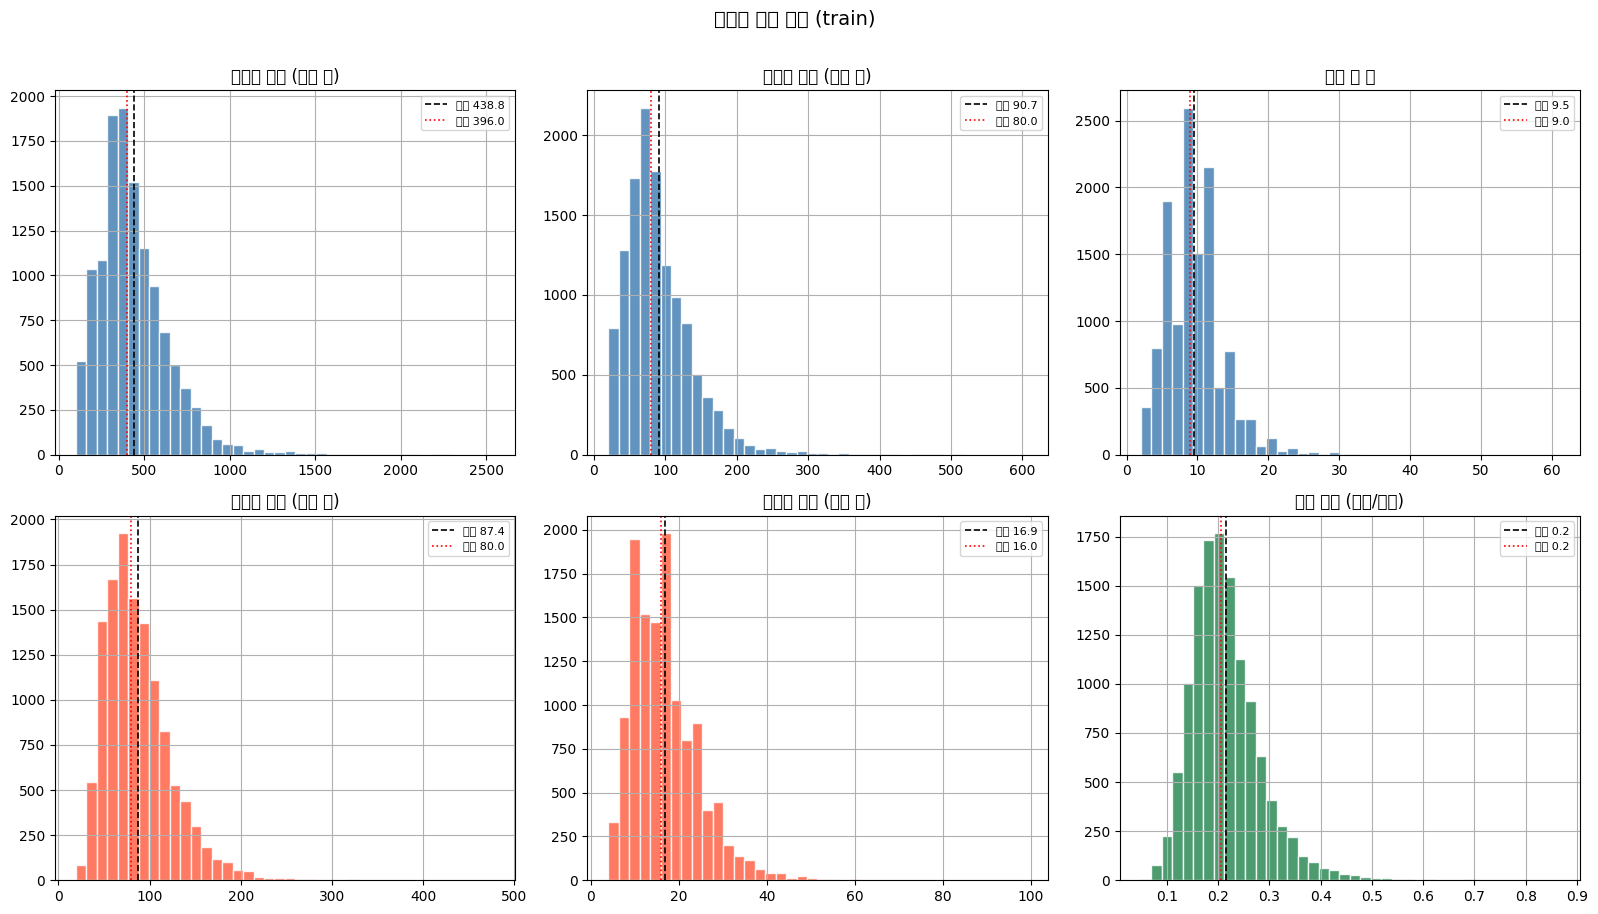

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('텍스트 길이 분포 (train)', fontsize=14, y=1.01)

plot_configs = [
    ('dialogue_len',      '대화문 길이 (문자 수)',     'steelblue'),
    ('dialogue_words',    '대화문 길이 (단어 수)',     'steelblue'),
    ('dialogue_turns',    '대화 턴 수',               'steelblue'),
    ('summary_len',       '요약문 길이 (문자 수)',     'tomato'),
    ('summary_words',     '요약문 길이 (단어 수)',     'tomato'),
    ('compression_ratio', '압축 비율 (요약/대화)',     'seagreen'),
]

for ax, (col, title, color) in zip(axes.flat, plot_configs):
    train[col].hist(bins=40, ax=ax, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.axvline(train[col].mean(),   color='black', linestyle='--', linewidth=1.2, label=f'평균 {train[col].mean():.1f}')
    ax.axvline(train[col].median(), color='red',   linestyle=':',  linewidth=1.2, label=f'중앙 {train[col].median():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 토픽 분포 분석

In [6]:
topic_counts = train['topic'].value_counts()
print(f'전체 토픽 수: {topic_counts.nunique()}개')
print('\n상위 20개 토픽:')
print(topic_counts.head(20).to_string())

전체 토픽 수: 46개

상위 20개 토픽:
topic
일상 대화      236
쇼핑         188
전화 통화       98
직업 면접       92
음식 주문       85
인터뷰         75
길 묻기        70
영화          48
사회적 만남      46
체크인         46
면접          45
날씨          44
여행          40
초대          38
주말 계획       35
정보 요청       34
휴가          34
길 안내        33
약속 잡기       31
비즈니스 대화     31


/tmp/ipykernel_335388/1304479622.py:8: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/1304479622.py:8: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/1304479622.py:8: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/1304479622.py:8: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/1304479622.py:8: UserWarning: Glyph 49660 (\N{HANGUL SYLLABLE SYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/1304479622.py:8: UserWarning: Glyph 54609 (\N{HANGUL SYLLABLE PING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/1304479622.py:8: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  pl

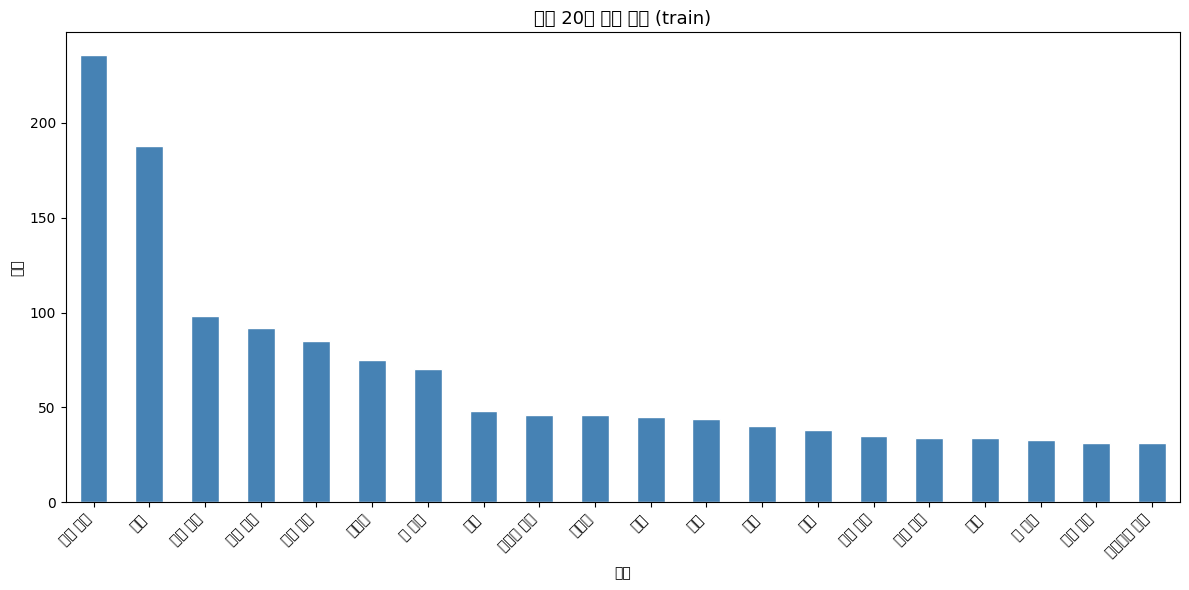

In [7]:
top_n = 20
fig, ax = plt.subplots(figsize=(12, 6))
topic_counts.head(top_n).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'상위 {top_n}개 토픽 분포 (train)', fontsize=13)
ax.set_xlabel('토픽')
ax.set_ylabel('빈도')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 화자(Person) 분석

/tmp/ipykernel_335388/2425001195.py:15: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2425001195.py:15: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2425001195.py:15: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2425001195.py:15: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2425001195.py:15: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2425001195.py:15: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/2425001195.py:15: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  

=== 화자 수 분포 (train) ===
num_speakers
2    12332
3      111
4        9
5        3
6        1
7        1


/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/co

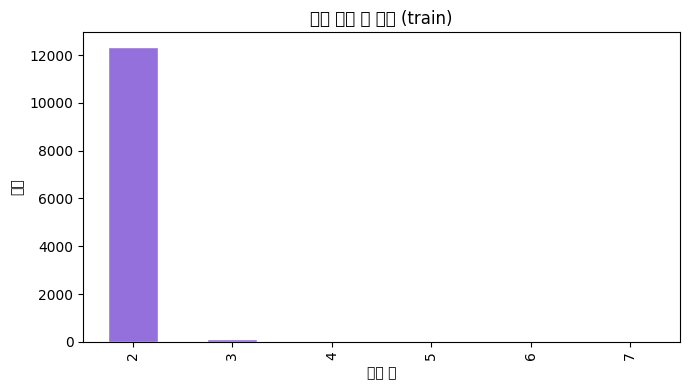

In [8]:
def count_speakers(text):
    return len(set(re.findall(r'#Person\d+#', text)))

train['num_speakers'] = train['dialogue'].apply(count_speakers)
dev['num_speakers']   = dev['dialogue'].apply(count_speakers)

print('=== 화자 수 분포 (train) ===')
print(train['num_speakers'].value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(7, 4))
train['num_speakers'].value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('대화 화자 수 분포 (train)')
ax.set_xlabel('화자 수')
ax.set_ylabel('빈도')
plt.tight_layout()
plt.savefig('../outputs/speaker_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Train / Dev 분포 비교

/tmp/ipykernel_335388/999869648.py:12: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/999869648.py:12: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/999869648.py:12: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/999869648.py:12: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/999869648.py:12: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/999869648.py:12: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_335388/999869648.py:12: UserWarning: Glyph 50557 (\N{HANGUL SYLLABLE YAG}) missing from font(s) DejaVu Sans.
  plt.tig

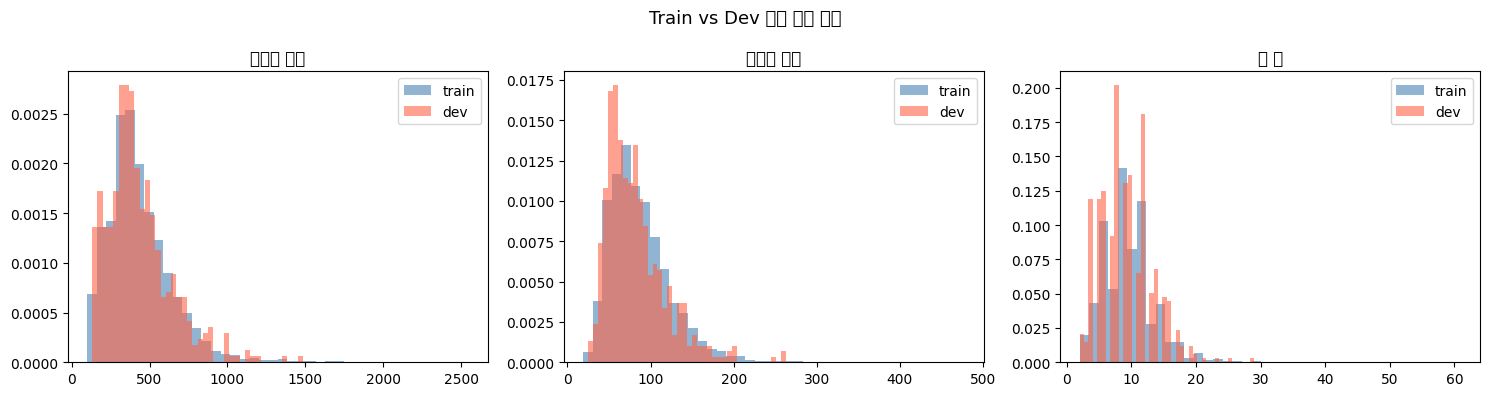

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Train vs Dev 길이 분포 비교', fontsize=13)

for ax, col, title in zip(axes,
    ['dialogue_len', 'summary_len', 'dialogue_turns'],
    ['대화문 길이', '요약문 길이', '턴 수']):
    ax.hist(train[col], bins=40, alpha=0.6, label='train', color='steelblue', density=True)
    ax.hist(dev[col],   bins=40, alpha=0.6, label='dev',   color='tomato',    density=True)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/train_dev_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 이상치 탐색

In [10]:
q99_dial = train['dialogue_len'].quantile(0.99)
q01_summ = train['summary_len'].quantile(0.01)
q99_summ = train['summary_len'].quantile(0.99)

long_dial  = train[train['dialogue_len'] > q99_dial]
short_summ = train[train['summary_len'] < q01_summ]

print(f'대화 길이 99th percentile : {q99_dial:.0f}자')
print(f'  → 초과 샘플 수          : {len(long_dial)}개')
print(f'\n요약 길이  1th percentile : {q01_summ:.0f}자')
print(f'  → 미만 샘플 수          : {len(short_summ)}개')

print('\n[대화 길이 상위 5개]')
display(long_dial[['fname', 'dialogue_len', 'summary_len', 'topic']].head())

print('\n[요약 길이 하위 5개]')
display(short_summ[['fname', 'dialogue_len', 'summary_len', 'summary', 'topic']].head())

대화 길이 99th percentile : 1202자
  → 초과 샘플 수          : 125개

요약 길이  1th percentile : 33자
  → 미만 샘플 수          : 121개

[대화 길이 상위 5개]


,fname,dialogue_len,summary_len,topic
210,train_210,1422,204,집 꾸미기
250,train_250,1365,192,토네이도 경보
258,train_258,1648,276,언어 교환
259,train_259,1369,195,장학금 신청하기
477,train_477,1236,241,과목 선택



[요약 길이 하위 5개]


,fname,dialogue_len,summary_len,summary,topic
88,train_88,183,30,#Person2#는 아버지를 화나게 해서 괴로워합니다.,아버지
299,train_299,215,25,#Person2#는 생맥주와 과일을 주문한다.,쇼핑
373,train_373,213,29,#Person1#은 류양에게 보고서 복사를 부탁한다.,보고서 복사
454,train_454,144,32,#Person1#이 안나에게 춤을 초대하고 가르칠 것이다.,춤 초대
472,train_472,135,32,#Person1#이 로스앤젤레스행 비행기에 대해 문의한다.,비행기 문의


## 8. 샘플 확인

In [11]:
def show_sample(df, idx=0):
    row = df.iloc[idx]
    print(f'[fname]   {row["fname"]}')
    print(f'[topic]   {row.get("topic", "N/A")}')
    print(f'\n[dialogue]\n{row["dialogue"]}')
    if 'summary' in row:
        print(f'\n[summary]\n{row["summary"]}')

print('=' * 60)
print('TRAIN 샘플')
print('=' * 60)
show_sample(train, idx=0)

TRAIN 샘플
[fname]   train_0
[topic]   건강검진 받기

[dialogue]
#Person1#: 안녕하세요, 스미스씨. 저는 호킨스 의사입니다. 오늘 왜 오셨나요?
#Person2#: 건강검진을 받는 것이 좋을 것 같아서요.
#Person1#: 그렇군요, 당신은 5년 동안 건강검진을 받지 않았습니다. 매년 받아야 합니다.
#Person2#: 알고 있습니다. 하지만 아무 문제가 없다면 왜 의사를 만나러 가야 하나요?
#Person1#: 심각한 질병을 피하는 가장 좋은 방법은 이를 조기에 발견하는 것입니다. 그러니 당신의 건강을 위해 최소한 매년 한 번은 오세요.
#Person2#: 알겠습니다.
#Person1#: 여기 보세요. 당신의 눈과 귀는 괜찮아 보입니다. 깊게 숨을 들이쉬세요. 스미스씨, 담배 피우시나요?
#Person2#: 네.
#Person1#: 당신도 알다시피, 담배는 폐암과 심장병의 주요 원인입니다. 정말로 끊으셔야 합니다. 
#Person2#: 수백 번 시도했지만, 습관을 버리는 것이 어렵습니다.
#Person1#: 우리는 도움이 될 수 있는 수업과 약물들을 제공하고 있습니다. 나가기 전에 더 많은 정보를 드리겠습니다.
#Person2#: 알겠습니다, 감사합니다, 의사선생님.

[summary]
스미스씨가 건강검진을 받고 있고, 호킨스 의사는 매년 건강검진을 받는 것을 권장합니다. 호킨스 의사는 스미스씨가 담배를 끊는 데 도움이 될 수 있는 수업과 약물에 대한 정보를 제공할 것입니다.


## 9. 분석 요약

In [12]:
summary_stats = pd.DataFrame({
    'split':            ['train', 'dev', 'test'],
    'samples':          [len(train), len(dev), len(test)],
    'dialogue_len_mean': [train['dialogue_len'].mean(), dev['dialogue_len'].mean(), test['dialogue_len'].mean()],
    'dialogue_len_max':  [train['dialogue_len'].max(),  dev['dialogue_len'].max(),  test['dialogue_len'].max()],
    'turns_mean':        [train['dialogue_turns'].mean(), dev['dialogue_turns'].mean(), test['dialogue_turns'].mean()],
}).set_index('split').round(1)

summary_stats['summary_len_mean'] = [
    train['summary_len'].mean(),
    dev['summary_len'].mean(),
    None
]

print('=== 데이터셋 요약 ===')
display(summary_stats)

=== 데이터셋 요약 ===


,samples,dialogue_len_mean,dialogue_len_max,turns_mean,summary_len_mean
split,,,,,
train,12457,438.8,2546,9.5,87.397929
dev,499,432.6,1484,9.4,81.709419
test,499,449.3,2650,9.7,NaN
